<a href="https://colab.research.google.com/github/VitorBZS/am-t4-s1a2026/blob/main/MultiNeuralCredit(Orange)0616.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pipeline Rondom Forest | Digest Pickle [Fase 1 - Credit Base]

## Importar dados do Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Bibliotecas de Python

In [ ]:
!pip -q install plotly
!pip -q install yellowbrick

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

## Carregar Digest de base_credit

In [ ]:
import pickle

In [ ]:
with open('/content/drive/MyDrive/amt4/credit.pkt', 'rb') as f:
  X_credit_treinamento, Y_credit_treinamento, X_credit_teste, Y_credit_teste = pickle.load(f)

In [ ]:
X_credit_treinamento.shape, Y_credit_treinamento.shape

((1700, 3), (1700,))

In [ ]:
X_credit_teste.shape, Y_credit_teste.shape

((300, 3), (300,))

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
random_credit = RandomForestClassifier(n_estimators=10, criterion='entropy', random_state=0)
random_credit.fit(X_credit_treinamento, Y_credit_treinamento)
RandomForestClassifier(bootstrap=True, ccp_alpha=0.0, class_weight=None,
                       criterion='entropy', max_depth=None, max_features='auto',
                       min_impurity_decrease=0.0, min_samples_split=None,
                       min_samples_leaf=1, min_weight_fraction_leaf=0.0, n_estimators=10,
                       n_jobs=None, oob_score=False, random_state=0, verbose=0, warm_start=False)

RandomForestClassifier(criterion='entropy', max_features='auto',
                       min_samples_split=None, n_estimators=10, random_state=0)

In [ ]:
previsores_random = random_credit.predict(X_credit_teste)
previsores_random

array([1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0])

## Criando base Previsora

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
accuracy_score(Y_credit_teste, previsores_random)

0.9733333333333334

In [ ]:
confusion_matrix(Y_credit_teste, previsores_random)

array([[257,   3],
       [  5,  35]])

In [ ]:
from yellowbrick.classifier import ConfusionMatrix

0.9733333333333334

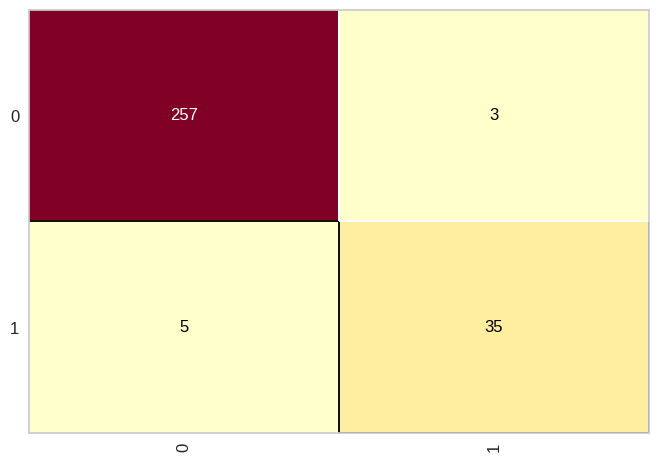

In [ ]:
cm_credit = ConfusionMatrix(random_credit)
cm_credit.fit(X_credit_treinamento, Y_credit_treinamento)
cm_credit.score(X_credit_teste, Y_credit_teste)

In [ ]:
print(classification_report(Y_credit_teste, previsores_random))

              precision    recall  f1-score   support

           0       0.98      0.99      0.98       260
           1       0.92      0.88      0.90        40

    accuracy                           0.97       300
   macro avg       0.95      0.93      0.94       300
weighted avg       0.97      0.97      0.97       300



# Pipeline Regressão | Digest [Fase 1 Credit Base]

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
regressao_credit = LogisticRegression(random_state=1)
regressao_credit.fit(X_credit_treinamento, Y_credit_treinamento)

LogisticRegression(random_state=1)

In [ ]:
LogisticRegression(C=1.0, class_weight=None, dual=False, fit_intercept=True,
                   intercept_scaling=1, l1_ratio=None, max_iter=100,
                   multi_class='auto', n_jobs=None, penalty='l2',
                   random_state=1, solver='lbfgs', tol=0.0001, verbose=0,
                   warm_start=False)

LogisticRegression(multi_class='auto', random_state=1)

In [ ]:
regression_previsores = regressao_credit.predict(X_credit_teste)
regression_previsores

array([1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0,
       1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0])

In [ ]:
accuracy_score(Y_credit_teste, regression_previsores)

0.9533333333333334

0.9533333333333334

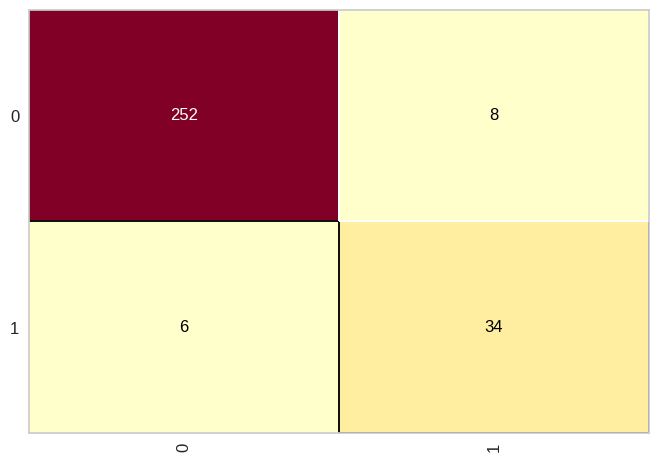

In [ ]:
from yellowbrick.classifier import ConfusionMatrix
cm_credit = ConfusionMatrix(regressao_credit)
cm_credit.fit(X_credit_treinamento, Y_credit_treinamento)
cm_credit.score(X_credit_teste, Y_credit_teste)

In [ ]:
print(classification_report(Y_credit_teste, regression_previsores))

              precision    recall  f1-score   support

           0       0.98      0.97      0.97       260
           1       0.81      0.85      0.83        40

    accuracy                           0.95       300
   macro avg       0.89      0.91      0.90       300
weighted avg       0.95      0.95      0.95       300



# Pipeline SVM | Digest [Fase 1 Credit Base]

In [ ]:
from sklearn.svm import SVC

In [ ]:
svm_credit = SVC(kernel='rbf', random_state=1, C=2.0)
svm_credit.fit(X_credit_treinamento, Y_credit_treinamento)

SVC(C=2.0, random_state=1)

In [ ]:
SVC(C=2.0, break_ties=False, cache_size=200, class_weight=None, coef0=0.0,
    decision_function_shape='ovr', degree=3, gamma='scale', kernel='rbf',
    max_iter=-1, probability=False, random_state=1, shrinking=True, tol=0.001,
    verbose=False)

SVC(C=2.0, random_state=1)

In [ ]:
svm_previsoes = svm_credit.predict(X_credit_teste)
svm_previsoes

array([1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0])

In [ ]:
accuracy_score(Y_credit_teste, svm_credit.predict(X_credit_teste))

0.9933333333333333

0.9933333333333333

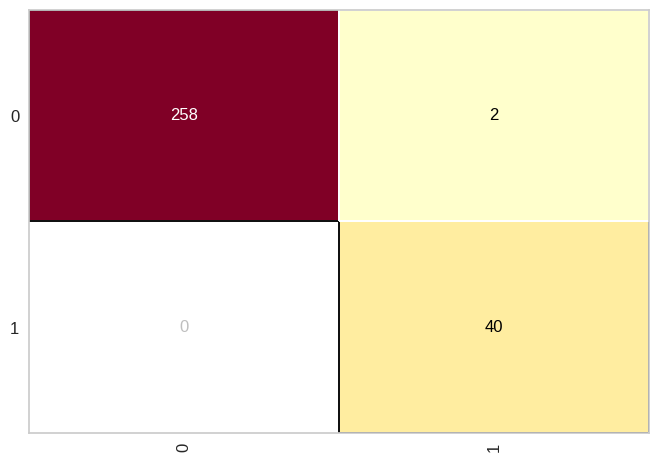

In [ ]:
svm_cm = ConfusionMatrix(svm_credit)
svm_cm.fit(X_credit_treinamento, Y_credit_treinamento)
svm_cm.score(X_credit_teste, Y_credit_teste)

In [ ]:
print(classification_report(Y_credit_teste, svm_previsoes))

              precision    recall  f1-score   support

           0       1.00      0.99      1.00       260
           1       0.95      1.00      0.98        40

    accuracy                           0.99       300
   macro avg       0.98      1.00      0.99       300
weighted avg       0.99      0.99      0.99       300



# Pipeline Redes Neurais | Digest [Fase 1 Credit Base]

In [ ]:
from sklearn.neural_network import MLPClassifier

In [ ]:
redeneural_credit = MLPClassifier(verbose =True, max_iter=1000, tol=0.000010, solver='adam', hidden_layer_sizes=(100),
                                  activation='relu')
redeneural_credit.fit(X_credit_treinamento, Y_credit_treinamento)

Iteration 1, loss = 0.56228445
Iteration 2, loss = 0.50415176
Iteration 3, loss = 0.45498725
Iteration 4, loss = 0.41432974
Iteration 5, loss = 0.37973030
Iteration 6, loss = 0.35062644
Iteration 7, loss = 0.32532341
Iteration 8, loss = 0.30304524
Iteration 9, loss = 0.28334454
Iteration 10, loss = 0.26586660
Iteration 11, loss = 0.25011133
Iteration 12, loss = 0.23632062
Iteration 13, loss = 0.22345998
Iteration 14, loss = 0.21201311
Iteration 15, loss = 0.20152738
Iteration 16, loss = 0.19212042
Iteration 17, loss = 0.18343816
Iteration 18, loss = 0.17556464
Iteration 19, loss = 0.16830764
Iteration 20, loss = 0.16173774
Iteration 21, loss = 0.15568634
Iteration 22, loss = 0.15003755
Iteration 23, loss = 0.14497947
Iteration 24, loss = 0.14012600
Iteration 25, loss = 0.13572197
Iteration 26, loss = 0.13164491
Iteration 27, loss = 0.12780468
Iteration 28, loss = 0.12439739
Iteration 29, loss = 0.12120654
Iteration 30, loss = 0.11813586
Iteration 31, loss = 0.11525610
Iteration 32, los

MLPClassifier(hidden_layer_sizes=100, max_iter=1000, tol=1e-05, verbose=True)

In [ ]:
redeneural_credit.out_activation_

'logistic'

In [ ]:
previsores_randeural = redeneural_credit.predict(X_credit_teste)
previsores_randeural

array([1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0])

In [ ]:
accuracy_score(Y_credit_teste, previsores_randeural)

0.9933333333333333

0.9933333333333333

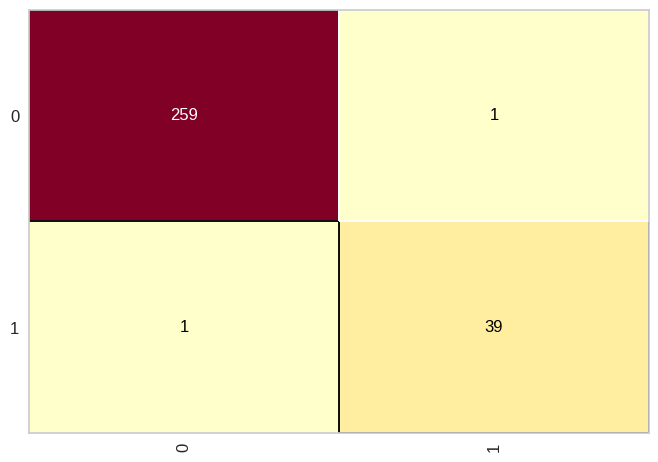

In [ ]:
rn_cm = ConfusionMatrix(redeneural_credit)
rn_cm.fit(X_credit_treinamento, Y_credit_treinamento)
rn_cm.score(X_credit_teste, Y_credit_teste)

In [ ]:
print(classification_report(Y_credit_teste, previsores_randeural))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       260
           1       0.97      0.97      0.97        40

    accuracy                           0.99       300
   macro avg       0.99      0.99      0.99       300
weighted avg       0.99      0.99      0.99       300



# Pipeline de Preparação dos Dados | Credit_Base[Fase 1]

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
parametros = {'n_neighbors': [3, 5, 10, 20],
              'p':[1,2]}

In [ ]:
grid_credit = GridSearchCV(estimator=KNeighborsClassifier(), param_grid = parametros)
grid_credit.fit(X_credit_treinamento, Y_credit_treinamento)
melhor_parametro_credit = grid_credit.best_params_
melhor_resultado_credit = grid_credit.best_score_
print(melhor_parametro_credit)
print(melhor_resultado_credit)

{'n_neighbors': 5, 'p': 2}
0.9823529411764707


# Pipeline de Orange | Credit_Base [Fase 1]

In [ ]:
!pip install Orange3

  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 16.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 86.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 538.0/538.0 kB 35.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 270.5/270.5 kB 21.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 71.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.9/125.9 kB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 15.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.4/51.4 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.0/95.0 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.6/70.6 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73

In [ ]:
import Orange

In [ ]:
base_orange_credit = Orange.data.Table('/content/drive/MyDrive/amt4/credit_data_regras.csv')
base_orange_credit.domain

[income, age, loan | default]

In [ ]:
credit_dividida = Orange.evaluation.testing.sample(base_orange_credit, n=0.25)

In [ ]:
credit_dividida

([[31210.8, 54.1049, 3853.09 | 0],
  [47770.7, 33.9494, 5366.87 | 0],
  [20943, 19.8196, 4098.12 | 1],
  [22372.5, 31.493, 1118.93 | 0],
  [21533.6, 57.9017, 1971.55 | 0],
  ...
 ],
 [[52143.8, 20.8376, 2393.1 | 0],
  [48270.8, 45.3059, 6232.28 | 0],
  [58216.1, 27.4045, 9581.83 | 1],
  [36088.9, 41.7178, 6222.42 | 0],
  [29933.2, 18.659, 5953.52 | 1],
  ...
 ])

In [ ]:
treinamento_credit = credit_dividida[1]
teste_credit = credit_dividida[0]

In [ ]:
cn2_credit = Orange.classification.rules.CN2Learner()
regras_credit = cn2_credit(treinamento_credit)

In [ ]:
for regras in regras_credit.rule_list:
  print(regras)

IF age>=34.9966813726351 THEN default=0 
IF income>=69478.3987640403 THEN default=1 
IF loan<=2495.13299137587 AND income>=20145.9885970689 THEN default=0 
IF income<=31702.3342987522 AND loan>=3665.88089899456 THEN default=1 
IF loan>=7660.34617051509 AND loan>=9704.7824094498 THEN default=1 
IF age>=34.851817262359 THEN default=0 
IF loan>=7660.34617051509 AND loan>=9595.28628892989 THEN default=0 
IF loan>=7660.34617051509 AND age>=20.9909665295854 THEN default=1 
IF income>=58132.4712652713 AND age>=20.5852316911332 THEN default=0 
IF income<=22089.8374845274 AND age>=21.3656869572587 THEN default=1 
IF age>=34.8313612546772 THEN default=1 
IF loan>=5862.83302915672 AND age>=23.5900381784886 THEN default=1 
IF loan>=7235.19471689825 THEN default=1 
IF income>=48552.843409124805 THEN default=0 
IF loan<=4849.33378471958 AND income>=38042.0841556042 THEN default=0 
IF age>=25.856677569914602 AND income>=45840.2076200582 THEN default=0 
IF income>=37887.5493933447 AND loan>=5416.35779

In [ ]:
credit_preview = Orange.evaluation.testing.TestOnTestData(treinamento_credit, teste_credit, [lambda testdata: regras_credit])


In [ ]:
credit_preview

In [ ]:
Orange.evaluation.CA(credit_preview)

array([0.982])